/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_4521/2244709965.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_4521/2244709965.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_4521/2244709965.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

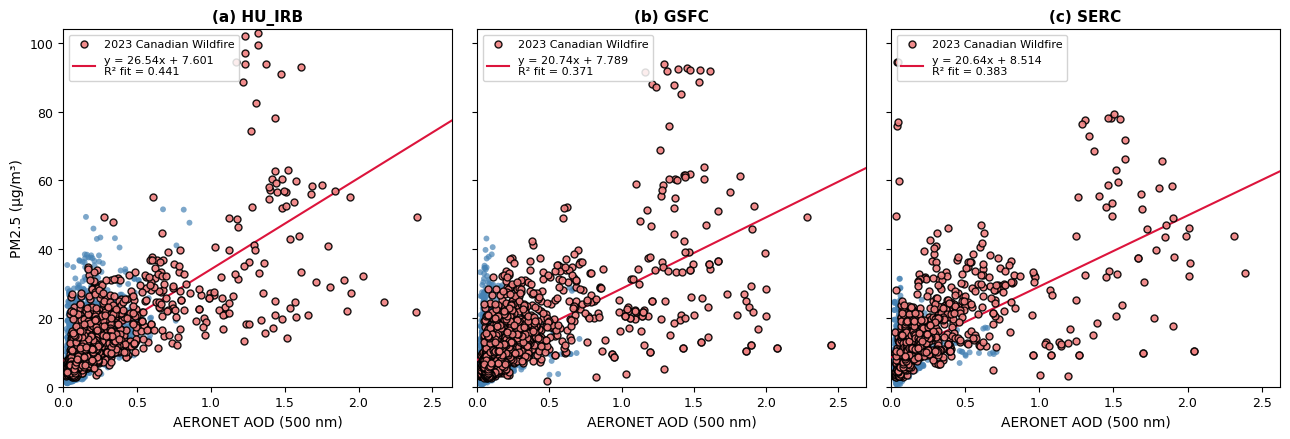

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

STATIONS = ["HU_IRB", "GSFC", "SERC"]
LABELS = ["(a)", "(b)", "(c)"]
FILL_VALUE = -999

matched_data = []

for site in STATIONS:
    ae = pd.read_csv(f"../data/{site}/{site}_AOD20_combined.csv", low_memory=False)
    
    ae["datetime"] = pd.to_datetime(
        ae["Date(dd:mm:yyyy)"] + " " + ae["Time(hh:mm:ss)"], 
        format="%d:%m:%Y %H:%M:%S"
    )
    
    cols_to_keep = ["datetime", "AOD_500nm"]
    ae = ae[cols_to_keep].replace(FILL_VALUE, np.nan).dropna()
    ae = ae[ae["datetime"].dt.year.between(2021, 2025)]
    
    ae_hourly = (
        ae.groupby(ae["datetime"].dt.floor("1h"))["AOD_500nm"]
        .mean()
        .reset_index()
    )
    
    pm25 = pd.read_csv(f"../data/pm25/{site}_pm25.csv", parse_dates=["datetime"])
    pm25 = pm25.dropna(subset=["PM2_5"])
    
    merged = pd.merge(ae_hourly, pm25, on="datetime", how="inner")
    merged["station"] = site
    matched_data.append(merged)

df_all = pd.concat(matched_data, ignore_index=True)

highlight_start = pd.Timestamp("2023-03-01")
highlight_end = pd.Timestamp("2023-09-30")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

for ax, site, label in zip(axes, STATIONS, LABELS):
    sub = df_all[df_all["station"] == site]
    
    mask = sub["datetime"].between(highlight_start, highlight_end)
    sub_high = sub[mask]
    sub_norm = sub[~mask]
    
    x = sub["AOD_500nm"].values
    y = sub["PM2_5"].values

    ax.scatter(sub_norm["AOD_500nm"], sub_norm["PM2_5"], s=18, color="steelblue", alpha=0.7, edgecolors="none", zorder=2)
    
    ax.scatter(sub_high["AOD_500nm"], sub_high["PM2_5"], s=25, color="lightcoral", alpha=0.9, edgecolors="black", zorder=4, label="2023 Canadian Wildfire")

    if len(x) > 0:
        lim_x = x.max() * 1.1
        lim_y = y.max() * 1.1
        ax.set_xlim(left=0, right=lim_x)
        ax.set_ylim(bottom=0, top=lim_y)

    if len(x) >= 2:
        slope, intercept, r_value, _, _ = stats.linregress(x, y)
        
        x_fit = np.linspace(0, lim_x, 200)
        legend_text = f"y = {slope:.2f}x + {intercept:.3f}\nR² fit = {r_value**2:.3f}"
        
        ax.plot(x_fit, slope * x_fit + intercept, color="crimson", linewidth=1.5, zorder=3, label=legend_text)
        ax.legend(fontsize=8, frameon=True, framealpha=0.85, loc="upper left")

    ax.set_xlabel("AERONET AOD (500 nm)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("PM2.5 (µg/m³)", fontsize=10)
        
    ax.set_title(f"{label} {site}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)

plt.tight_layout()
# plt.savefig("../data/AERONET_PM25_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_4521/554302802.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_4521/554302802.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ae["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_4521/554302802.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

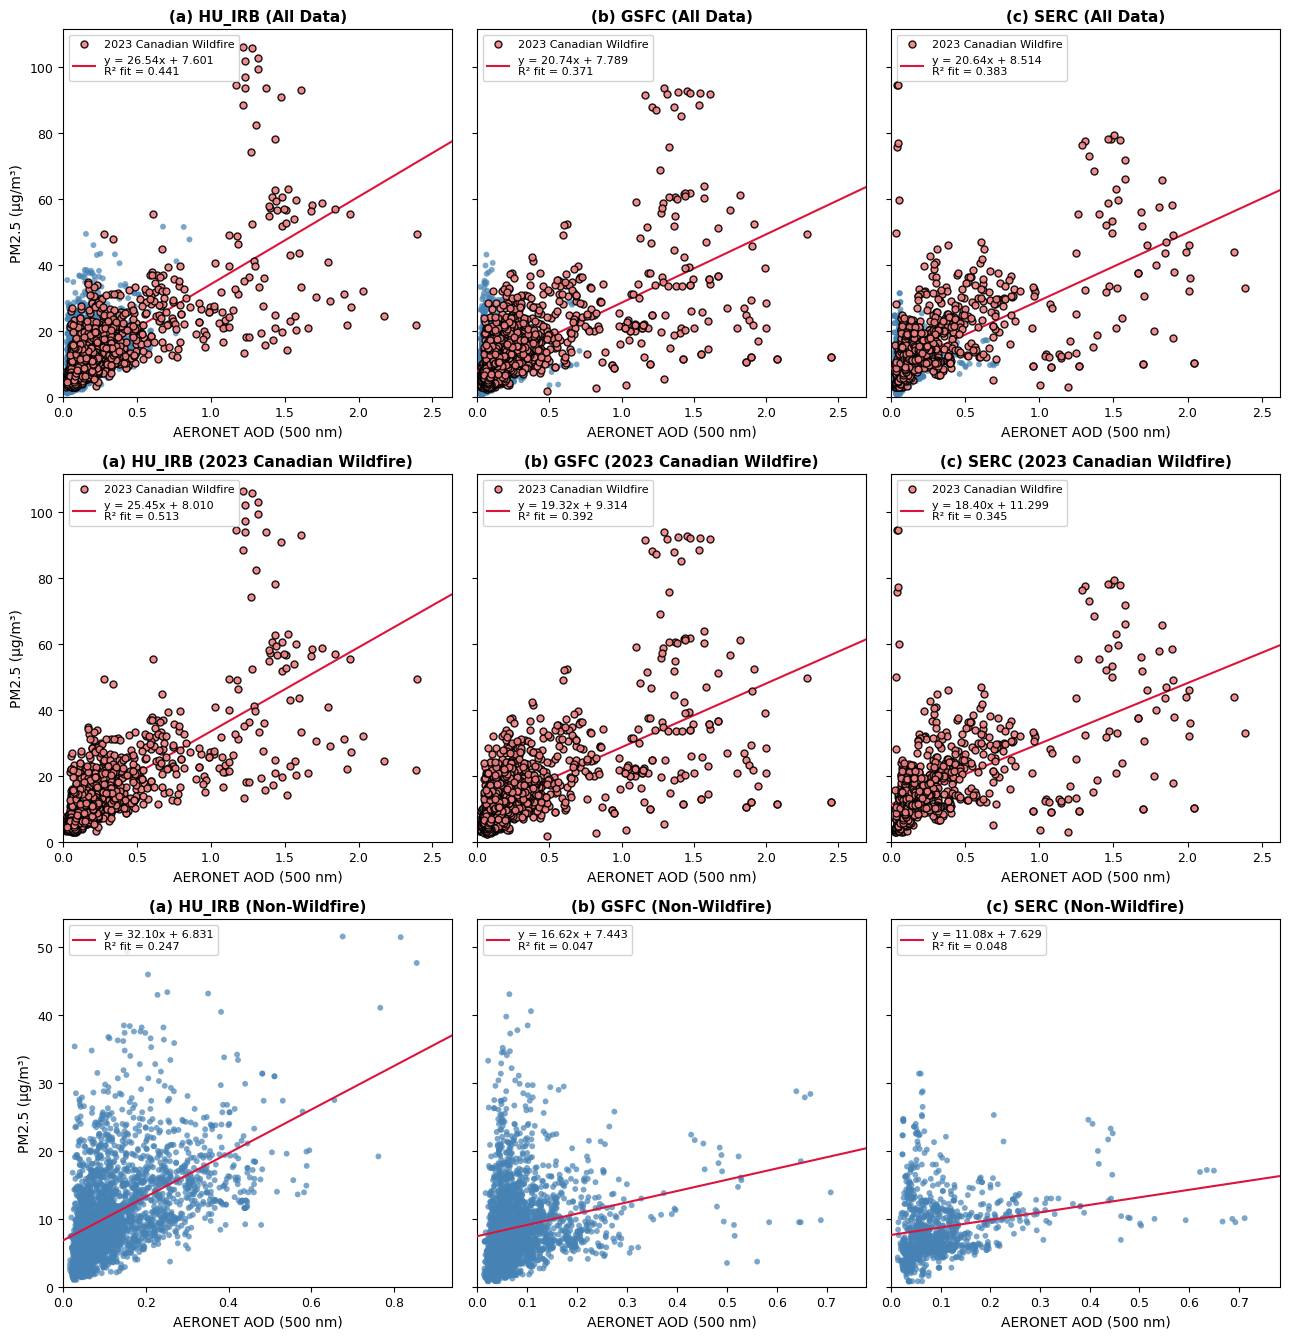

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

STATIONS = ["HU_IRB", "GSFC", "SERC"]
LABELS = ["(a)", "(b)", "(c)"]
FILL_VALUE = -999

matched_data = []

for site in STATIONS:
    ae = pd.read_csv(f"../data/{site}/{site}_AOD20_combined.csv", low_memory=False)
    
    ae["datetime"] = pd.to_datetime(
        ae["Date(dd:mm:yyyy)"] + " " + ae["Time(hh:mm:ss)"], 
        format="%d:%m:%Y %H:%M:%S"
    )
    
    cols_to_keep = ["datetime", "AOD_500nm"]
    ae = ae[cols_to_keep].replace(FILL_VALUE, np.nan).dropna()
    ae = ae[ae["datetime"].dt.year.between(2021, 2025)]
    
    ae_hourly = (
        ae.groupby(ae["datetime"].dt.floor("1h"))["AOD_500nm"]
        .mean()
        .reset_index()
    )
    
    pm25 = pd.read_csv(f"../data/pm25/{site}_pm25.csv", parse_dates=["datetime"])
    pm25 = pm25.dropna(subset=["PM2_5"])
    
    merged = pd.merge(ae_hourly, pm25, on="datetime", how="inner")
    merged["station"] = site
    matched_data.append(merged)

df_all = pd.concat(matched_data, ignore_index=True)

highlight_start = pd.Timestamp("2023-03-01")
highlight_end = pd.Timestamp("2023-09-30")

# Share the y-axis strictly across rows
fig, axes = plt.subplots(3, 3, figsize=(13, 13.5), sharey="row")
row_titles = ["All Data", "2023 Canadian Wildfire", "Non-Wildfire"]

for col, site in enumerate(STATIONS):
    sub = df_all[df_all["station"] == site]
    
    mask = sub["datetime"].between(highlight_start, highlight_end)
    sub_high = sub[mask]
    sub_norm = sub[~mask]
    
    datasets = [
        (sub, True), 
        (sub_high, False), 
        (sub_norm, False)
    ]

    for row, (data, is_mixed) in enumerate(datasets):
        ax = axes[row, col]
        x = data["AOD_500nm"].values
        y = data["PM2_5"].values

        if is_mixed:
            ax.scatter(sub_norm["AOD_500nm"], sub_norm["PM2_5"], s=18, color="steelblue", alpha=0.7, edgecolors="none", zorder=2)
            ax.scatter(sub_high["AOD_500nm"], sub_high["PM2_5"], s=25, color="lightcoral", alpha=0.9, edgecolors="black", zorder=4, label="2023 Canadian Wildfire")
        elif row == 1:
            ax.scatter(x, y, s=25, color="lightcoral", alpha=0.9, edgecolors="black", zorder=4, label="2023 Canadian Wildfire")
        else:
            ax.scatter(x, y, s=18, color="steelblue", alpha=0.7, edgecolors="none", zorder=2)

        if len(x) > 0:
            lim_x = x.max() * 1.1
            ax.set_xlim(left=0, right=lim_x)
            # Remove top=lim_y so the shared row axis can auto-scale to the true maximum
            ax.set_ylim(bottom=0)

        if len(x) >= 2:
            slope, intercept, r_value, _, _ = stats.linregress(x, y)
            x_fit = np.linspace(0, lim_x if len(x) > 0 else 1, 200)
            legend_text = f"y = {slope:.2f}x + {intercept:.3f}\nR² fit = {r_value**2:.3f}"
            
            ax.plot(x_fit, slope * x_fit + intercept, color="crimson", linewidth=1.5, zorder=3, label=legend_text)
            ax.legend(fontsize=8, frameon=True, framealpha=0.85, loc="upper left")

        ax.set_xlabel("AERONET AOD (500 nm)", fontsize=10)
        if col == 0:
            ax.set_ylabel("PM2.5 (µg/m³)", fontsize=10)
            
        ax.set_title(f"{LABELS[col]} {site} ({row_titles[row]})", fontsize=11, fontweight="bold")
        ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("../data/AERONET_PM25_scatter.png", dpi=300, bbox_inches="tight")
plt.show()